In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import splitfolders
from tensorflow.keras.utils import image_dataset_from_directory

In [5]:
import re

old_data = '../data/Driver Drowsiness Dataset (DDD)'
classes = ['Drowsy', 'Non Drowsy']

def get_subject(filename):
    return re.match(r'^([A-Za-z]+)', os.path.basename(filename)).group(1).upper()

for cls in classes:
    src_dir = os.path.join(old_data, cls)
    files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]
    subject_counts = {}
    for f in files:
        s = get_subject(f)
        subject_counts[s] = subject_counts.get(s, 0) + 1
    print(f"\n{cls} — {len(subject_counts)} subjects, {len(files)} total frames")
    for s, c in sorted(subject_counts.items()):
        print(f"  {s}: {c} frames")


Drowsy — 28 subjects, 22348 total frames
  A: 1411 frames
  B: 315 frames
  C: 335 frames
  D: 179 frames
  E: 962 frames
  F: 415 frames
  G: 499 frames
  H: 508 frames
  I: 1095 frames
  J: 474 frames
  K: 630 frames
  L: 732 frames
  M: 777 frames
  N: 1156 frames
  O: 1097 frames
  P: 963 frames
  Q: 562 frames
  R: 204 frames
  S: 487 frames
  T: 933 frames
  U: 420 frames
  V: 653 frames
  W: 1162 frames
  X: 1749 frames
  Y: 1112 frames
  ZA: 621 frames
  ZB: 1551 frames
  ZC: 1346 frames

Non Drowsy — 26 subjects, 19445 total frames
  A: 1252 frames
  B: 409 frames
  C: 400 frames
  D: 1005 frames
  E: 1000 frames
  G: 109 frames
  H: 571 frames
  I: 1045 frames
  J: 717 frames
  K: 538 frames
  L: 381 frames
  M: 473 frames
  N: 957 frames
  O: 671 frames
  P: 190 frames
  Q: 521 frames
  R: 522 frames
  S: 457 frames
  U: 510 frames
  V: 1002 frames
  W: 493 frames
  X: 1143 frames
  Y: 1500 frames
  ZA: 1054 frames
  ZB: 1237 frames
  ZC: 1288 frames


In [6]:
# Assign subjects to splits using the union across both classes
# so a subject's drowsy and non-drowsy frames always land in the same split
rng = np.random.default_rng(42)

all_subjects = set()
for cls in classes:
    src_dir = os.path.join(old_data, cls)
    files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]
    all_subjects.update(get_subject(f) for f in files)

subjects = sorted(all_subjects)
rng.shuffle(subjects)

n = len(subjects)
n_val  = max(1, round(n * 0.15))
n_test = max(1, round(n * 0.15))

subject_split = {}
for s in subjects[:n_val]:
    subject_split[s] = 'val'
for s in subjects[n_val:n_val + n_test]:
    subject_split[s] = 'test'
for s in subjects[n_val + n_test:]:
    subject_split[s] = 'train'

for split in ('train', 'val', 'test'):
    members = sorted(s for s, sp in subject_split.items() if sp == split)
    print(f"{split} ({len(members)} subjects): {members}")

train (20 subjects): ['A', 'B', 'C', 'D', 'E', 'G', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'S', 'T', 'U', 'V', 'ZA', 'ZB']
val (4 subjects): ['H', 'Q', 'W', 'X']
test (4 subjects): ['F', 'R', 'Y', 'ZC']


In [7]:
import shutil

split_data = '../data/split_data'

shutil.rmtree(split_data, ignore_errors=True)
for split in ('train', 'val', 'test'):
    for cls in classes:
        os.makedirs(os.path.join(split_data, split, cls), exist_ok=True)

for cls in classes:
    src_dir = os.path.join(old_data, cls)
    files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]
    counts = {'train': 0, 'val': 0, 'test': 0}

    for f in files:
        subj = get_subject(f)
        split = subject_split[subj]
        shutil.copy(os.path.join(src_dir, f), os.path.join(split_data, split, cls, f))
        counts[split] += 1

    print(f"{cls}: train={counts['train']}  val={counts['val']}  test={counts['test']}")

Drowsy: train=15290  val=3981  test=3077
Non Drowsy: train=13407  val=2728  test=3310


In [8]:
BATCH_SIZE = 128
IMG_SIZE = (128, 128)

train_dataset = image_dataset_from_directory(
      '../data/split_data/train',
      shuffle=True,
      batch_size=BATCH_SIZE,
      image_size=IMG_SIZE,
      seed=42
  )

validation_dataset = image_dataset_from_directory(
    '../data/split_data/val',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=42
)

test_dataset = image_dataset_from_directory(
    '../data/split_data/test',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=42
)

Found 28697 files belonging to 2 classes.
Found 6709 files belonging to 2 classes.
Found 6387 files belonging to 2 classes.


2026-08-29 14:07:13.115123: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


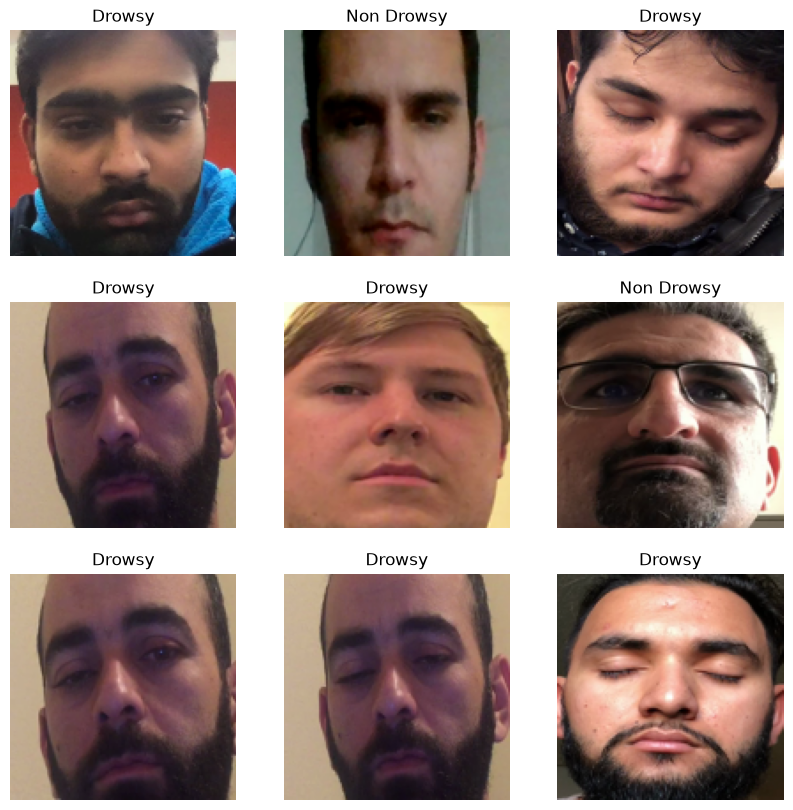

In [9]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.regularizers import l2

In [11]:
model = Sequential([
    Conv2D(8, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3), kernel_regularizer=l2(0.01)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(16, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    GlobalAveragePooling2D(),
    Dense(16, activation='relu', 
          kernel_regularizer=l2(0.01)),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])


/Users/lukeconran/Core/college/hackathons/tamuhack2024/ready-alert/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,801 (26.57 KB)

 Trainable params: 6,689 (26.13 KB)

 Non-trainable params: 112 (448.00 B)

In [19]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [20]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.8865 - loss: 0.6866 - val_accuracy: 0.7952 - val_loss: 1.1253 - learning_rate: 0.0010
Epoch 2/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9652 - loss: 0.3252 - val_accuracy: 0.7020 - val_loss: 2.2202 - learning_rate: 0.0010
Epoch 3/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9863 - loss: 0.2018 - val_accuracy: 0.5727 - val_loss: 2.0651 - learning_rate: 0.0010
Epoch 4/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.9925 - loss: 0.1544 - val_accuracy: 0.6213 - val_loss: 1.4770 - learning_rate: 5.0000e-04
Epoch 5/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.9946 - loss: 0.1271 - val_accuracy: 0.6020 - val_loss: 1.8543 - learning_rate: 5.0000e-04
Epoch 6/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.9951 - loss: 0.1171 - val_accuracy: 0.7643 - val_loss: 1.8023 - learning_rate: 2.5000e-04


In [21]:
model.evaluate(test_dataset)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3827 - loss: 1.3615


[1.6439311504364014, 0.453264445066452]

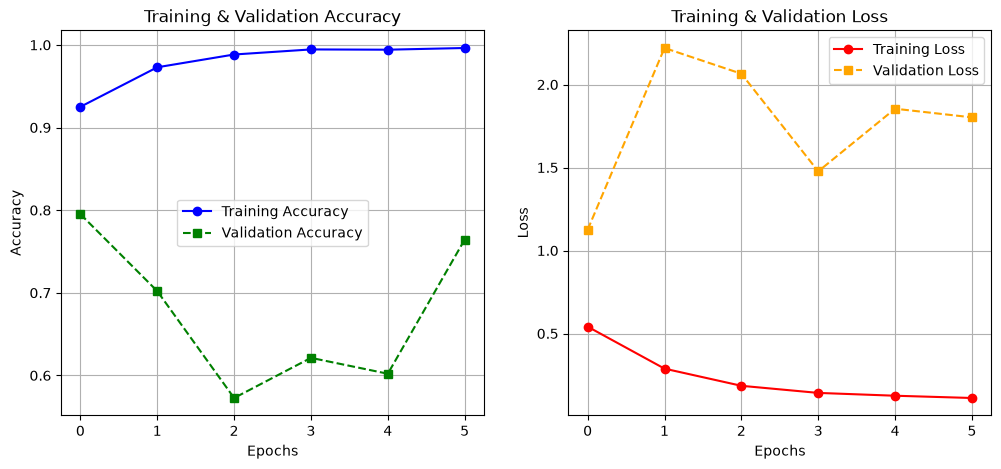

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy", color="blue", marker="o", linestyle="-")
plt.plot(epochs_range, val_acc, label="Validation Accuracy", color="green", marker="s", linestyle="--")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss", color="red", marker="o", linestyle="-")
plt.plot(epochs_range, val_loss, label="Validation Loss", color="orange", marker="s", linestyle="--")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.grid(True)

plt.show()

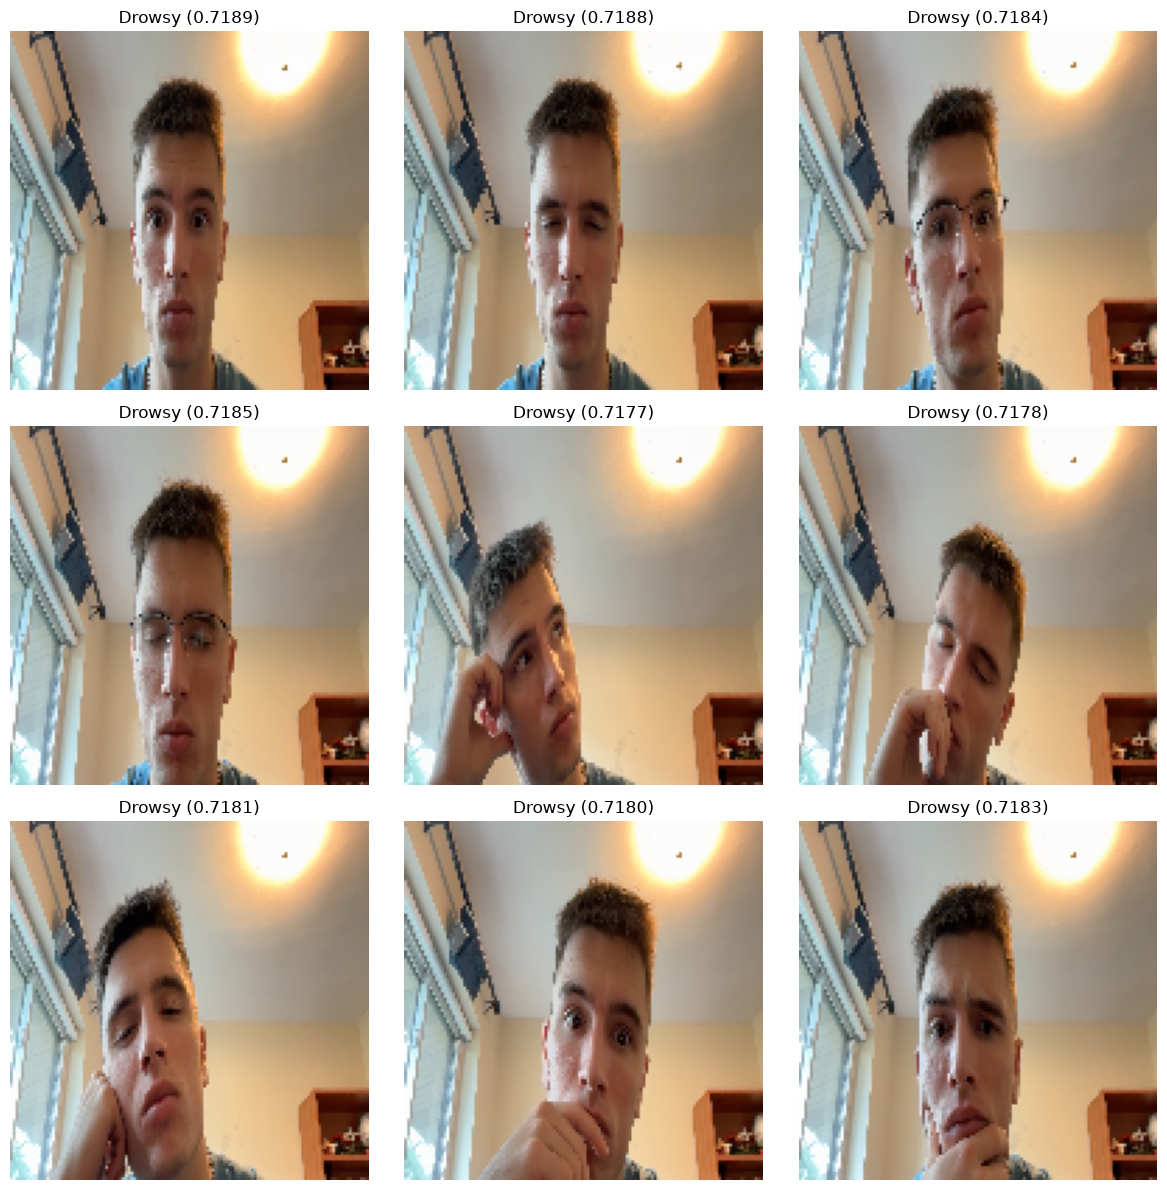

In [23]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

selfie_dir = '../data/selfies'
selfie_paths = sorted([
    os.path.join(selfie_dir, f)
    for f in os.listdir(selfie_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

class_names = test_dataset.class_names  # e.g. ['Drowsy', 'Non Drowsy']

def preprocess_image(image_path):
    img = load_img(image_path, target_size=(128, 128))
    img_array = img_to_array(img) / 255.0
    return img, np.expand_dims(img_array, axis=0)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, path in enumerate(selfie_paths[:9]):
    img, img_array = preprocess_image(path)
    pred = model.predict(img_array, verbose=0)[0][0]
    class_idx = 1 if pred > 0.5 else 0
    label = class_names[class_idx]
    confidence = pred if class_idx == 1 else 1 - pred

    axes[i].imshow(img)
    axes[i].set_title(f"{label} ({confidence:.4f})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


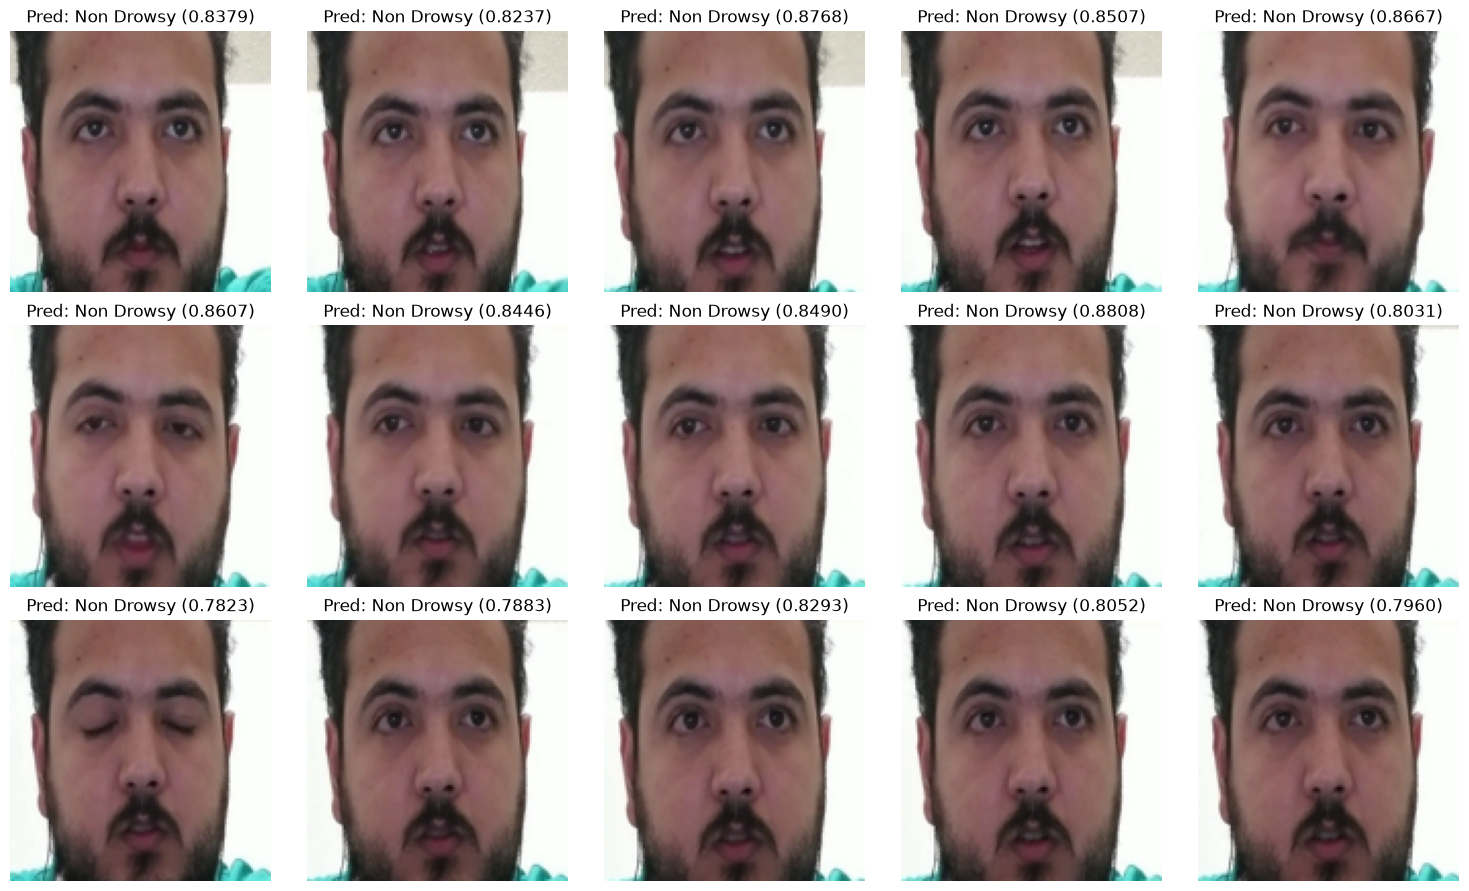

Predictions for displayed images:
Image 1: Predicted Class: Non Drowsy, Confidence: 0.8379
Image 2: Predicted Class: Non Drowsy, Confidence: 0.8237
Image 3: Predicted Class: Non Drowsy, Confidence: 0.8768
Image 4: Predicted Class: Non Drowsy, Confidence: 0.8507
Image 5: Predicted Class: Non Drowsy, Confidence: 0.8667
Image 6: Predicted Class: Non Drowsy, Confidence: 0.8607
Image 7: Predicted Class: Non Drowsy, Confidence: 0.8446
Image 8: Predicted Class: Non Drowsy, Confidence: 0.8490
Image 9: Predicted Class: Non Drowsy, Confidence: 0.8808
Image 10: Predicted Class: Non Drowsy, Confidence: 0.8031
Image 11: Predicted Class: Non Drowsy, Confidence: 0.7823
Image 12: Predicted Class: Non Drowsy, Confidence: 0.7883
Image 13: Predicted Class: Non Drowsy, Confidence: 0.8293
Image 14: Predicted Class: Non Drowsy, Confidence: 0.8052
Image 15: Predicted Class: Non Drowsy, Confidence: 0.7960


In [24]:
num_images = 15

images, true_labels = next(iter(test_dataset))

images = images[:num_images]
true_labels = true_labels[:num_images]

predictions = model.predict(images)

class_indices = test_dataset.class_names
class_names_map = {i: name for i, name in enumerate(class_indices)}

rows = (num_images + 4) // 5
cols = min(num_images, 5)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if num_images > 1 else [axes]

for i in range(num_images):
    img = images[i]
    pred_prob = predictions[i][0]
    pred_class = 1 if pred_prob > 0.5 else 0
    pred_label = class_names_map[pred_class]
    confidence = pred_prob if pred_class == 1 else 1 - pred_prob

    axes[i].imshow(img.numpy().astype("uint8"))
    axes[i].set_title(f"Pred: {pred_label} ({confidence:.4f})")
    axes[i].axis('off')

for i in range(num_images, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("Predictions for displayed images:")
for i in range(num_images):
    pred_prob = predictions[i][0]
    pred_class = 1 if pred_prob > 0.5 else 0
    pred_label = class_names_map[pred_class]
    confidence = pred_prob if pred_class == 1 else 1 - pred_prob
    print(f"Image {i+1}: Predicted Class: {pred_label}, Confidence: {confidence:.4f}")